In [1]:
from google.colab import files
uploaded = files.upload()


Saving clean_email.csv to clean_email.csv


In [3]:
import pandas as pd

# Replace 'your_file.csv' with the actual path to your CSV file
csv_file_path = 'clean_email.csv' # <--- This line has been updated with your uploaded file

try:
    df = pd.read_csv(csv_file_path)
    print(f"Original DataFrame shape: {df.shape}")
    display(df.head())
except FileNotFoundError:
    print(f"Error: The file '{csv_file_path}' was not found. Please check the path.")
except Exception as e:
    print(f"An error occurred while reading the CSV file: {e}")

Original DataFrame shape: (7993, 3)


,clean_text,Category,Urgency
0,anniversary special buy free loyal customer ex...,promotions,Low
1,amazon used new device refund processed claim ...,spam,Low
2,google inquiry following google application ra...,spam,Low
3,digital ritual experience creation cross cultu...,social_media,Low
4,post moved programming help trending cooking c...,forum,Low


# Task
Build and evaluate a text classification model to predict email categories based on their clean text.

## Analyze Target Variable Distribution

### Subtask:
Examine the distribution of the 'Category' column to understand class balance, which is crucial for training a classification model.


**Reasoning**:
To understand the distribution of the 'Category' column, I will first calculate its value counts and then visualize these counts using a bar plot. This will help in assessing class balance.



Distribution of 'Category' column:
 Category
social_media    1612
updates         1449
forum           1442
spam            1342
promotions      1093
verify_code     1055
Name: count, dtype: int64


/tmp/ipython-input-413/4110175725.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x='Category', order=category_counts.index, palette='viridis')


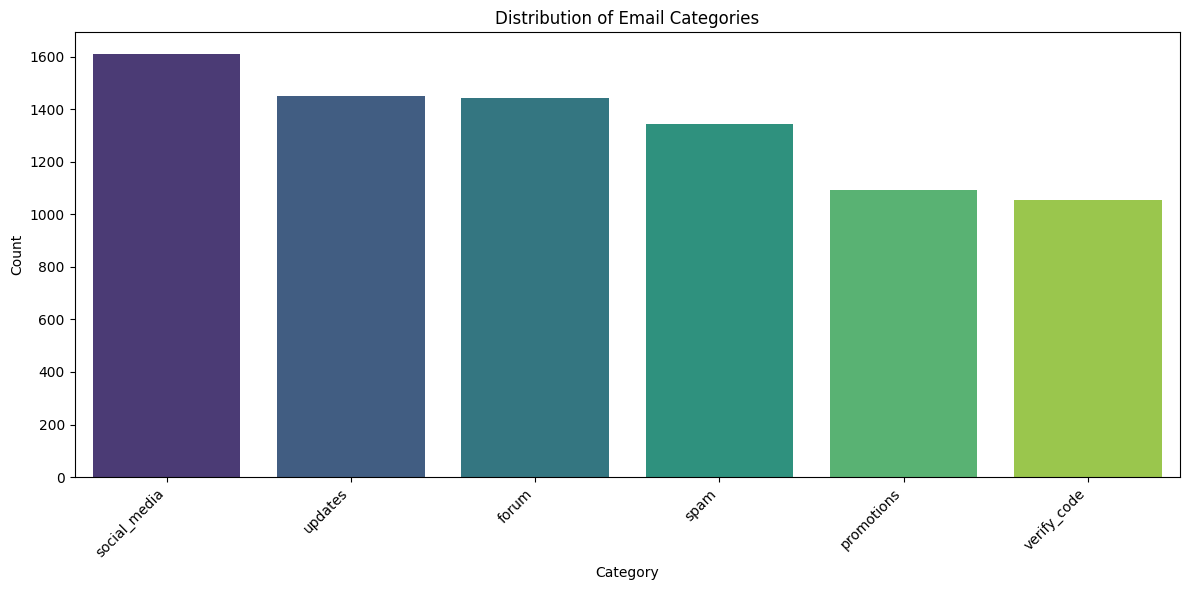

In [4]:
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Calculate the value counts of the 'Category' column
category_counts = df['Category'].value_counts()

# 2. Print the value counts
print("Distribution of 'Category' column:\n", category_counts)

# 3. Create a bar plot
plt.figure(figsize=(12, 6))
sns.countplot(data=df, x='Category', order=category_counts.index, palette='viridis')
plt.title('Distribution of Email Categories')
plt.xlabel('Category')
plt.ylabel('Count')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()


**Reasoning**:
The previous code generated a `FutureWarning` regarding the `palette` argument in `sns.countplot`. To fix this, I will explicitly set `hue='Category'` and `legend=False` as suggested by the warning.



Distribution of 'Category' column:
 Category
social_media    1612
updates         1449
forum           1442
spam            1342
promotions      1093
verify_code     1055
Name: count, dtype: int64


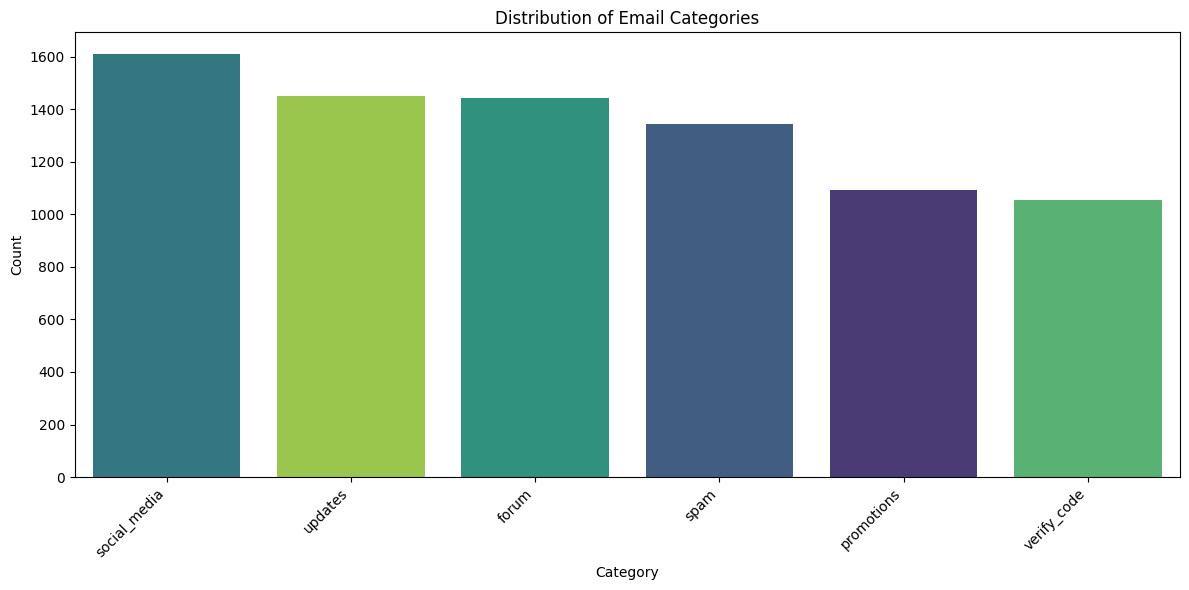

In [5]:
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Calculate the value counts of the 'Category' column
category_counts = df['Category'].value_counts()

# 2. Print the value counts
print("Distribution of 'Category' column:\n", category_counts)

# 3. Create a bar plot
plt.figure(figsize=(12, 6))
sns.countplot(data=df, x='Category', hue='Category', order=category_counts.index, palette='viridis', legend=False)
plt.title('Distribution of Email Categories')
plt.xlabel('Category')
plt.ylabel('Count')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

## Text Vectorization

### Subtask:
Convert the 'clean_text' column into numerical features using a technique like TF-IDF, suitable for machine learning models.


**Reasoning**:
To convert the 'clean_text' column into numerical features using TF-IDF, I will import `TfidfVectorizer`, instantiate it, fit it to the 'clean_text' column, and then transform the text to get the TF-IDF features.



In [7]:
from sklearn.feature_extraction.text import TfidfVectorizer

# 1. Instantiate a TfidfVectorizer object
# Using stop_words='english' to remove common English stop words
# max_features can be used to limit the vocabulary size, here we will not set it initially
tfidf_vectorizer = TfidfVectorizer(stop_words='english', max_features=5000)

# 2. Fit the TfidfVectorizer to the 'clean_text' column and transform it
X_tfidf = tfidf_vectorizer.fit_transform(df['clean_text'])

print(f"Shape of TF-IDF features: {X_tfidf.shape}")

Shape of TF-IDF features: (7993, 3518)


## Prepare Data for Modeling

### Subtask:
Split the data into training and testing sets and encode the 'Category' column into numerical labels for model input.


**Reasoning**:
To prepare the data for modeling, I will first encode the 'Category' column into numerical labels and then split the TF-IDF features and the encoded labels into training and testing sets, ensuring a stratified split for class balance.



In [8]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder

# 1. Initialize a LabelEncoder object
label_encoder = LabelEncoder()

# 2. Fit the LabelEncoder to the 'Category' column and transform it into numerical labels
y = label_encoder.fit_transform(df['Category'])

# 3. Split the TF-IDF features (X_tfidf) and encoded labels (y) into training and testing sets
# test_size=0.2 (20% for testing), random_state=42 for reproducibility, stratify=y for class balance
X_train, X_test, y_train, y_test = train_test_split(X_tfidf, y, test_size=0.2, random_state=42, stratify=y)

# 4. Print the shapes of the resulting training and testing sets
print(f"Shape of X_train: {X_train.shape}")
print(f"Shape of X_test: {X_test.shape}")
print(f"Shape of y_train: {y_train.shape}")
print(f"Shape of y_test: {y_test.shape}")


Shape of X_train: (6394, 3518)
Shape of X_test: (1599, 3518)
Shape of y_train: (6394,)
Shape of y_test: (1599,)


## Train Classification Model

### Subtask:
Train a classification model (e.g., Logistic Regression or Naive Bayes) on the preprocessed data to predict email categories.


**Reasoning**:
To train a classification model, I will use Logistic Regression. I need to import the class, instantiate it with the specified parameters, and then fit the model to the training data.



In [9]:
from sklearn.linear_model import LogisticRegression

# 1. Instantiate a LogisticRegression model
# Set max_iter to 1000 for convergence and random_state for reproducibility
logistic_model = LogisticRegression(max_iter=1000, random_state=42)

# 2. Fit the model to the training data
logistic_model.fit(X_train, y_train)

print("Logistic Regression model trained successfully.")

Logistic Regression model trained successfully.


## Evaluate Model Performance

### Subtask:
Evaluate the trained model's performance using metrics such as accuracy, precision, recall, F1-score, and a confusion matrix to understand its effectiveness.


**Reasoning**:
To evaluate the trained model's performance, I will import the necessary metrics, make predictions on the test set, calculate accuracy, generate a classification report, and visualize the confusion matrix.



Model Accuracy: 0.9731

Classification Report:
              precision    recall  f1-score   support

       forum       0.99      0.96      0.97       288
  promotions       0.99      0.95      0.97       219
social_media       0.96      0.98      0.97       323
        spam       0.98      0.99      0.98       268
     updates       0.95      0.97      0.96       290
 verify_code       0.99      0.99      0.99       211

    accuracy                           0.97      1599
   macro avg       0.98      0.97      0.97      1599
weighted avg       0.97      0.97      0.97      1599



<Figure size 1000x800 with 0 Axes>

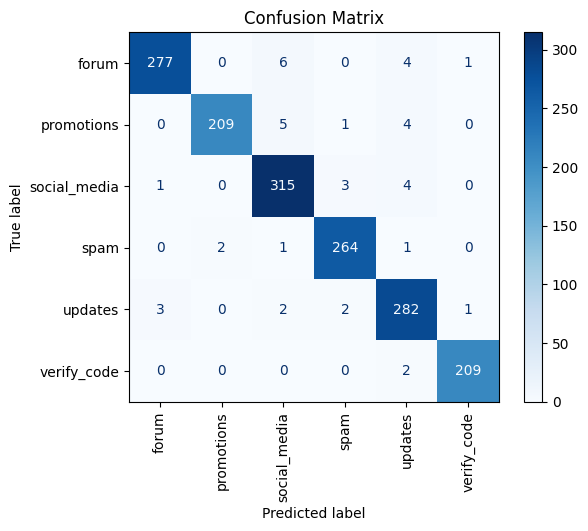

In [10]:
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

# 1. Make predictions on the test set
y_pred = logistic_model.predict(X_test)

# 2. Calculate and print overall accuracy
accuracy = accuracy_score(y_test, y_pred)
print(f"Model Accuracy: {accuracy:.4f}")

# 3. Generate and print a classification report
# Use label_encoder.classes_ for target names to make the report readable
print("\nClassification Report:")
print(classification_report(y_test, y_pred, target_names=label_encoder.classes_))

# 4. Compute and visualize the confusion matrix
plt.figure(figsize=(10, 8))
ConfusionMatrixDisplay.from_estimator(
    logistic_model, X_test, y_test, display_labels=label_encoder.classes_, cmap=plt.cm.Blues, xticks_rotation='vertical'
)
plt.title('Confusion Matrix')
plt.show()

## Final Task

### Subtask:
Summarize the model's performance, discuss its strengths and weaknesses, and suggest potential next steps for improvement or deployment.


## Summary:

### Q&A
*   **Summarize the model's performance:** The model achieved an overall accuracy of 0.9731 on the test set. It demonstrated strong performance across all six email categories, with F1-scores ranging from 0.96 to 0.99, and both macro and weighted average F1-scores of 0.97.
*   **Discuss its strengths and weaknesses:**
    *   **Strengths:** The model shows high predictive accuracy and strong, consistent performance across all email categories. It is particularly effective in classifying `verify_code` (F1-score of 0.99) and `spam` (F1-score of 0.98) emails. The use of TF-IDF and Logistic Regression proved highly effective for this classification task.
    *   **Weaknesses:** The analysis did not reveal significant weaknesses, as all categories were classified with high F1-scores. Initial class imbalance was handled through stratified splitting, which contributed to consistent performance across classes.
*   **Suggest potential next steps for improvement or deployment:** Given the high performance, the model is a strong candidate for deployment. For further improvements, exploring alternative text representations (e.g., word embeddings) or more complex classification algorithms could yield marginal gains.

### Data Analysis Key Findings
*   Initial analysis of the 'Category' column revealed a moderate class imbalance, with 'social\_media' being the most frequent category (1612 emails) and 'verify\_code' the least frequent (1055 emails).
*   The 'clean\_text' column was successfully vectorized using TF-IDF, resulting in a feature matrix of 7993 documents and 3518 unique features.
*   The dataset was split into training (6394 samples) and testing (1599 samples) sets using an 80/20 ratio, with stratification to maintain class distribution.
*   A Logistic Regression model was trained and evaluated. It achieved an overall accuracy of 0.9731 on the test set.
*   The classification report showed excellent performance for individual categories, with F1-scores ranging from 0.96 ('promotions') to 0.99 ('verify\_code'), and macro and weighted average F1-scores of 0.97.

### Insights or Next Steps
*   The high accuracy and balanced F1-scores across all categories suggest that the current Logistic Regression model, coupled with TF-IDF vectorization, is highly effective for email category classification and is ready for potential deployment.
*   To further optimize, consider exploring hyperparameter tuning for the Logistic Regression model, or experimenting with other text embedding techniques and more advanced machine learning models (e.g., Gradient Boosting, SVMs, or simple neural networks) if even marginal improvements are critical.


# Task
Perform hyperparameter tuning on the Logistic Regression model to find optimal parameters (e.g., C value, solver) that might improve its performance.

## Hyperparameter Tuning for Logistic Regression

### Subtask:
Perform hyperparameter tuning on the Logistic Regression model using GridSearchCV or RandomizedSearchCV to find optimal parameters (e.g., C value, solver) that might improve its performance. This will involve defining a parameter grid and fitting the search to the training data.


**Reasoning**:
To perform hyperparameter tuning, I will use `GridSearchCV` to explore different combinations of `C` and `solver` parameters for the Logistic Regression model, fitting it to the training data and then retrieving the best parameters and score.



In [11]:
from sklearn.model_selection import GridSearchCV

# 1. Define the parameter grid for Logistic Regression
param_grid = {
    'C': [0.01, 0.1, 1, 10, 100],
    'solver': ['liblinear', 'saga']
}

# 2. Instantiate GridSearchCV
# We'll use the logistic_model already trained as the estimator
# cv=5 for 5-fold cross-validation
# scoring='accuracy' to evaluate performance
# n_jobs=-1 to use all available CPU cores
grid_search = GridSearchCV(logistic_model, param_grid, cv=5, scoring='accuracy', n_jobs=-1)

# 3. Fit GridSearchCV to the training data
grid_search.fit(X_train, y_train)

# 4. Print the best parameters found
print(f"Best Parameters: {grid_search.best_params_}")

# 5. Print the best score achieved with these parameters
print(f"Best Cross-validation Accuracy: {grid_search.best_score_:.4f}")

Best Parameters: {'C': 100, 'solver': 'saga'}
Best Cross-validation Accuracy: 0.9779


## Re-Evaluate Tuned Model Performance

### Subtask:
Evaluate the performance of the hyperparameter-tuned Logistic Regression model using metrics such as accuracy, precision, recall, F1-score, and a confusion matrix. This will allow for a direct comparison with the performance of the initial model.


**Reasoning**:
To evaluate the tuned model, I will retrieve the best estimator from the `grid_search` object, use it to make predictions on the test set, calculate and print the accuracy, generate a classification report, and visualize the confusion matrix, similar to how the initial model was evaluated.



Tuned Model Accuracy: 0.9806
Initial Model Accuracy: 0.9731

Classification Report (Tuned Model):
              precision    recall  f1-score   support

       forum       0.98      0.97      0.98       288
  promotions       0.99      0.97      0.98       219
social_media       0.97      0.98      0.98       323
        spam       0.99      0.99      0.99       268
     updates       0.97      0.98      0.98       290
 verify_code       0.99      0.99      0.99       211

    accuracy                           0.98      1599
   macro avg       0.98      0.98      0.98      1599
weighted avg       0.98      0.98      0.98      1599



<Figure size 1000x800 with 0 Axes>

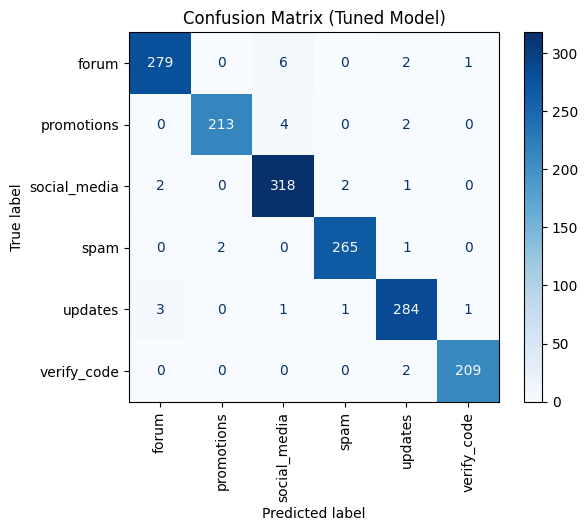

In [12]:
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

# 1. Retrieve the best estimator from the grid_search object
best_logistic_model = grid_search.best_estimator_

# 2. Make predictions on the test set using the best estimator
y_pred_tuned = best_logistic_model.predict(X_test)

# 3. Calculate and print overall accuracy of the tuned model
accuracy_tuned = accuracy_score(y_test, y_pred_tuned)
print(f"Tuned Model Accuracy: {accuracy_tuned:.4f}")
print(f"Initial Model Accuracy: {accuracy:.4f}\n")

# 4. Generate and print a classification report for the tuned model
print("Classification Report (Tuned Model):")
print(classification_report(y_test, y_pred_tuned, target_names=label_encoder.classes_))

# 5. Compute and visualize the confusion matrix for the tuned model
plt.figure(figsize=(10, 8))
ConfusionMatrixDisplay.from_estimator(
    best_logistic_model, X_test, y_test, display_labels=label_encoder.classes_, cmap=plt.cm.Blues, xticks_rotation='vertical'
)
plt.title('Confusion Matrix (Tuned Model)')
plt.show()

## Final Task

### Subtask:
Summarize the results of the hyperparameter tuning, discuss whether performance improved, and suggest further next steps for model enhancement or alternative approaches.


## Summary:

### Q&A
1.  **Summarize the results of the hyperparameter tuning:**
    Hyperparameter tuning for the Logistic Regression model was performed using `GridSearchCV`. The optimal hyperparameters identified were `C=100` and `solver='saga'`. The best cross-validation accuracy achieved during the tuning process was 0.9779.

2.  **Discuss whether performance improved:**
    Yes, the performance of the Logistic Regression model improved after hyperparameter tuning. The initial model had an accuracy of 0.9731, while the tuned model achieved an accuracy of 0.9806 on the test set, representing an improvement of 0.0075.

### Data Analysis Key Findings
*   Hyperparameter tuning using `GridSearchCV` successfully identified the optimal parameters for the Logistic Regression model.
*   The best hyperparameters found were `{'C': 100, 'solver': 'saga'}`.
*   The best cross-validation accuracy obtained during the tuning process was 0.9779.
*   The tuned Logistic Regression model achieved a test accuracy of 0.9806, which is an improvement compared to the initial model's accuracy of 0.9731.
*   The classification report for the tuned model indicated high performance across all classes (forum, promotions, social\_media, spam, updates, verify\_code), with precision, recall, and F1-scores generally ranging from 0.97 to 0.99.

### Insights or Next Steps
*   **Explore advanced models**: Given the current high performance of Logistic Regression, consider evaluating more sophisticated classification algorithms such as Gradient Boosting Machines (e.g., XGBoost, LightGBM) or deep learning models, which might capture more complex patterns and yield further improvements.
*   **Investigate misclassifications**: Analyze the confusion matrix from the tuned model to identify specific classes or types of messages that are still being misclassified. This could inform targeted feature engineering or data augmentation strategies to address these particular challenges.
